Classificação de espécies de pinguins

Integrantes: Maria Fernanda Courbassier | Eliseu Portes

Objetivo: usar as características dos pinguins para identificar
as espécies Adelie, Chinstrap e Gentoo com SVC e GridSearchCV.

Fonte dos dados:
https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data

Arquivo utilizado: penguins_size.csv

In [2]:
#carregar os dados
from google.colab import files
arquivos = files.upload()

Saving penguins_size.csv to penguins_size (1).csv


In [3]:
import pandas as pd
#le o arquivo e considero o "." como valor ausente
dados = pd.read_csv("penguins_size.csv", na_values=["."])
dados.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [4]:
print("Linhas e colunas", dados.shape) #tamanho da tabela
print("\nValores ausentes: ")
print(dados.isna().sum()) #conta os valores ausentes
print("\nQuantidade por espécie: ")
print(dados["species"].value_counts()) #faz a contagem por espécie
print("\nLinhas duplicadas:", dados.duplicated().sum()) #conta as linhas duplicadas

Linhas e colunas (344, 7)

Valores ausentes: 
species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Quantidade por espécie: 
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Linhas duplicadas: 0


In [5]:
#separar as características dos pinguins
x = dados.drop(columns=["species"])

#definie a espécie como resposta
y = dados["species"]

In [6]:
from sklearn.model_selection import train_test_split

#separa os dados de treino e teste
x_treino, x_teste, y_treino, y_teste = train_test_split(
    x,
    y,
    test_size=0.2, #reserva 20%
    random_state=42,
    stratify=y #manter a proporção aproximadamente
)

print("Treino: ", len(x_treino))
print("Teste: ", len(x_teste))


Treino:  275
Teste:  69


In [7]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#medidas das colunas
numericas = [
    "culmen_length_mm",
    "culmen_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

#colunas com categorias
categoricas = ["island", "sex"]

#preencher as meddias ausentes  e ajustar
tratamento_numerico = Pipeline([
    ("preencher", SimpleImputer(strategy="median")),
    ("padronizar", StandardScaler())
])

#preencher as categorias ausentes e transformar
tratamento_categorico = Pipeline ([
    ("preencher", SimpleImputer(strategy="most_frequent")),
    ("codificar", OneHotEncoder(handle_unknown="ignore"))
])

#aplicar cada tratamento nas colunas certas
preparo = ColumnTransformer([
    ("numericas", tratamento_numerico, numericas),
    ("categoricas", tratamento_categorico, categoricas)
])

print(numericas)
print(x_treino[numericas].head())

['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']
     culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
98               33.1             16.1              178.0       2900.0
114              39.6             20.7              191.0       3900.0
118              35.7             17.0              189.0       3350.0
303              50.0             15.9              224.0       5350.0
343              49.9             16.1              213.0       5400.0


In [8]:
from sklearn.svm import SVC

# Junta o tratamento dos dados com o modelo
modelo = Pipeline([
    ("preparo", preparo),
    ("svc", SVC())
])

In [9]:
from sklearn.model_selection import GridSearchCV

#definir as config que vai ser testado
parametros = {
    "svc__C": [0.1, 1, 10],
    "svc__kernel": ["linear", "rbf"]
}

#comparar as config em 5 partes
busca = GridSearchCV(
    modelo,
    parametros,
    cv=5,
    scoring="accuracy"
)

#faz a busca, usando apenas os dados de treino
busca.fit(x_treino, y_treino)

print("Melhores parâmetros:", busca.best_params_)
print("Acurácia na validação: ", round(busca.best_score_, 4))


Melhores parâmetros: {'svc__C': 1, 'svc__kernel': 'linear'}
Acurácia na validação:  0.9927


In [10]:
from sklearn.metrics import accuracy_score, classification_report

#usa o melhor modelo pra prever as espécies
previsoes = busca.predict(x_teste)

#compara as previsões com as respostas corretas
acuracia = accuracy_score(y_teste, previsoes)

print("Acurácia no teste: ", round(acuracia * 100, 2), "%")

print(classification_report(y_teste, previsoes))

Acurácia no teste:  98.55 %
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        30
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           0.99        69
   macro avg       0.98      0.99      0.98        69
weighted avg       0.99      0.99      0.99        69



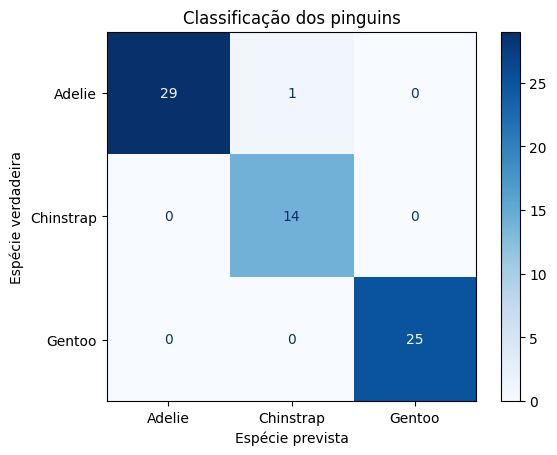

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#erros e acertos por especie
ConfusionMatrixDisplay.from_predictions(
    y_teste,
    previsoes,
    cmap="Blues"
)

plt.title("Classificação dos pinguins")
plt.xlabel("Espécie prevista")
plt.ylabel("Espécie verdadeira")

plt.show()


**Conclusão**

Usamos o SVC para classificar três espécies de pinguins. Antes do treinamento, preenchemos os valores ausentes, padronizamos as medidas e transformamos as categorias em números.

O GridSearchCV escolheu o kernel linear com C = 1. No teste, o modelo acertou 68 dos 69 pinguins, alcançando 98,55% de acurácia. O único erro foi um pinguim Adelie classificado como Chinstrap.

O resultado foi bom nesse conjunto de teste, mas pode variar quando o modelo recebe novos dados.